<a href="https://colab.research.google.com/github/Pranjli-S/DS-Assignments-2026/blob/main/Assignment-02/Movie_Production_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
"""
ASSIGNMENT 02: MOVIE INDUSTRY ANALYSIS
STUDENT NAME: Pranjli Singh
BTech CSE (2nd year)


PROBLEM STATEMENT:
You have been hired by a rookie movie producer to help him decide what type of movies to produce
and which actors to cast. You have to back your recommendations based on thorough analysis of
the data he shared with you which has the list of 3000 movies and the corresponding details.

As a data scientist, you have to first explore the data and check its sanity.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Setting the visual style for all plots
sns.set_theme(style="whitegrid")

In [12]:
# Loading the primary dataset
df = pd.read_csv('imdb_data.csv')

# Checking Sanity
print(f"Dataset Shape: {df.shape}")
print(f"Null Values Check:\n{df[['budget', 'revenue', 'genres', 'cast', 'crew']].isnull().sum()}")

# Parsing JSON columns
def parse_json(x):
    if pd.isna(x): return []
    try: return ast.literal_eval(x)
    except: return []

df['genres_list'] = df['genres'].apply(parse_json)
df['cast_list'] = df['cast'].apply(parse_json)
df['crew_list'] = df['crew'].apply(parse_json)

# Feature Extraction
df['genre_names'] = df['genres_list'].apply(lambda x: [i['name'] for i in x])
df['actor_names'] = df['cast_list'].apply(lambda x: [i['name'] for i in x])
df['director_names'] = df['crew_list'].apply(lambda x: [i['name'] for i in x if i['job'] == 'Director'])
df['producer_names'] = df['crew_list'].apply(lambda x: [i['name'] for i in x if i['job'] == 'Producer'])

# Calculating Profit and ROI
df['profit'] = df['revenue'] - df['budget']
df['roi'] = df['profit'] / df['budget'].replace(0, np.nan)

Dataset Shape: (3000, 23)
Null Values Check:
budget      0
revenue     0
genres      7
cast       13
crew       16
dtype: int64


In [13]:
print("Q1: Which movie made the highest profit? Who were its producer and director? Identify the actors in that film.")

top_movie = df.loc[df['profit'].idxmax()]
print("-" * 30)
print(f"Movie: {top_movie['title']}")
print(f"Profit: ${top_movie['profit']:,}")
print(f"Producers: {', '.join(top_movie['producer_names'])}")
print(f"Directors: {', '.join(top_movie['director_names'])}")
print(f"Lead Actors: {', '.join(top_movie['actor_names'][:10])}")

Q1: Which movie made the highest profit? Who were its producer and director? Identify the actors in that film.
------------------------------
Movie: Furious 7
Profit: $1,316,249,360
Producers: Vin Diesel, Neal H. Moritz, Michael Fottrell, Brandon Birtell
Directors: James Wan
Lead Actors: Vin Diesel, Paul Walker, Dwayne Johnson, Michelle Rodriguez, Tyrese Gibson, Ludacris, Jordana Brewster, Djimon Hounsou, Tony Jaa, Ronda Rousey


In [14]:
print("Q2: Which language has the highest average ROI (return on investment)?")

lang_stats = df.groupby('original_language')['roi'].mean()
print("-" * 30)
print(f"The language with highest average ROI is: {lang_stats.idxmax()}")
print(f"Average ROI for this language: {lang_stats.max():.2f}")

Q2: Which language has the highest average ROI (return on investment)?
------------------------------
The language with highest average ROI is: ko
Average ROI for this language: 381794.10


In [15]:
print("Q3: Find out the unique genres of movies in this dataset.")

all_genres = [g for sublist in df['genre_names'] for g in sublist]
unique_genres = sorted(list(set(all_genres)))
print("-" * 30)
print(f"Unique Genres found: {unique_genres}")


Q3: Find out the unique genres of movies in this dataset.
------------------------------
Unique Genres found: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


In [16]:
print("Q4: Find the top 3 producers who have produced movies with the highest average RoI?")

# Exploding producers to analyze individually
prod_df = df.explode('producer_names')
top_producers = prod_df.groupby('producer_names')['roi'].mean().sort_values(ascending=False).head(3)

print("-" * 30)
print("Top 3 Producers by ROI:")
print(top_producers)

Q4: Find the top 3 producers who have produced movies with the highest average RoI?
------------------------------
Top 3 Producers by ROI:
producer_names
Ji Sang-yong    4197475.625
Lee Eun-ha      4197475.625
Jang Jin        4197475.625
Name: roi, dtype: float64


In [17]:
print("Q5: Which actor has acted in the most number of movies? Deep dive into their movies.")

all_actors = [a for sub in df['actor_names'] for a in sub]
top_actor = pd.Series(all_actors).value_counts().idxmax()
actor_movies = df[df['actor_names'].apply(lambda x: top_actor in x)]

print("-" * 30)
print(f"Most Frequent Actor: {top_actor}")
print(f"Total Movies: {len(actor_movies)}")
display(actor_movies[['title', 'genre_names', 'profit']].head(10))

Q5: Which actor has acted in the most number of movies? Deep dive into their movies.
------------------------------
Most Frequent Actor: Samuel L. Jackson
Total Movies: 30


,title,genre_names,profit
29,Changing Lanes,"[Action, Adventure, Crime, Thriller]",49935764
47,The Hateful Eight,"[Crime, Drama, Mystery, Western]",111760117
642,Coming to America,"[Comedy, Romance]",249752301
689,Star Wars: Episode III - Revenge of the Sith,"[Science Fiction, Adventure, Action]",737000000
1055,Meeting Evil,"[Crime, Drama, Mystery, Thriller]",525
1126,The Avengers,"[Science Fiction, Action, Adventure]",1299557910
1181,Jumper,"[Adventure, Fantasy, Science Fiction]",137231186
1426,Shaft,"[Action, Adventure, Crime, Thriller]",61196498
1482,Snakes on a Plane,"[Action, Crime, Horror, Thriller]",29022014
1585,The Man,"[Action, Comedy, Crime]",12382362


In [18]:
print("Q6: Top 3 directors prefer which actors the most?")

top_3_dirs = pd.Series([d for sub in df['director_names'] for d in sub]).value_counts().head(3).index

print("-" * 30)
for director in top_3_dirs:
    dir_films = df[df['director_names'].apply(lambda x: director in x)]
    actor_roster = [a for sub in dir_films['actor_names'] for a in sub]
    favorite = pd.Series(actor_roster).value_counts().head(3)
    print(f"Director '{director}' most frequently casts: {', '.join(favorite.index)}")

Q6: Top 3 directors prefer which actors the most?
------------------------------
Director 'Ron Howard' most frequently casts: Clint Howard, Rance Howard, James Ritz
Director 'Clint Eastwood' most frequently casts: Clint Eastwood, Laura Linney, Doug McGrath
Director 'Steven Spielberg' most frequently casts: Harrison Ford, Pat Roach, Tom Hanks


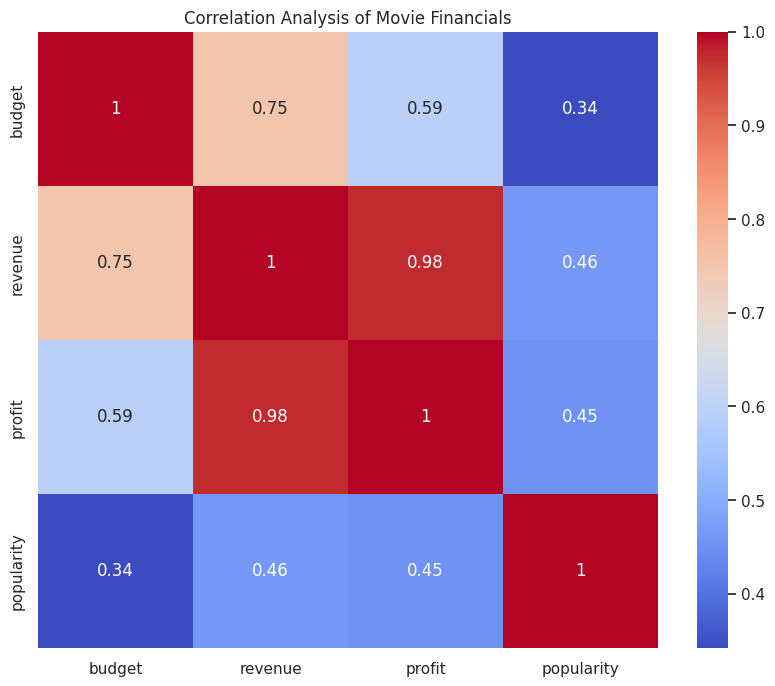

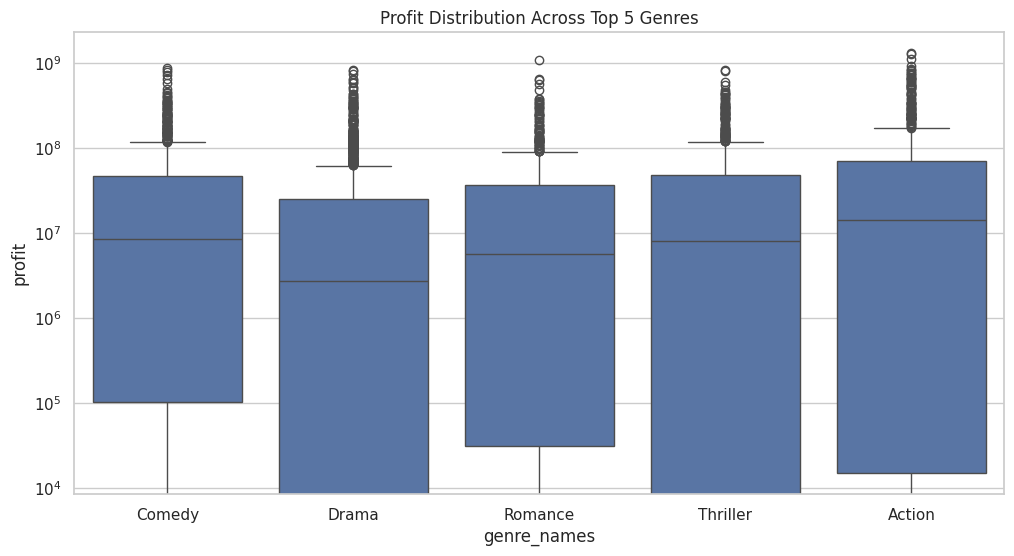

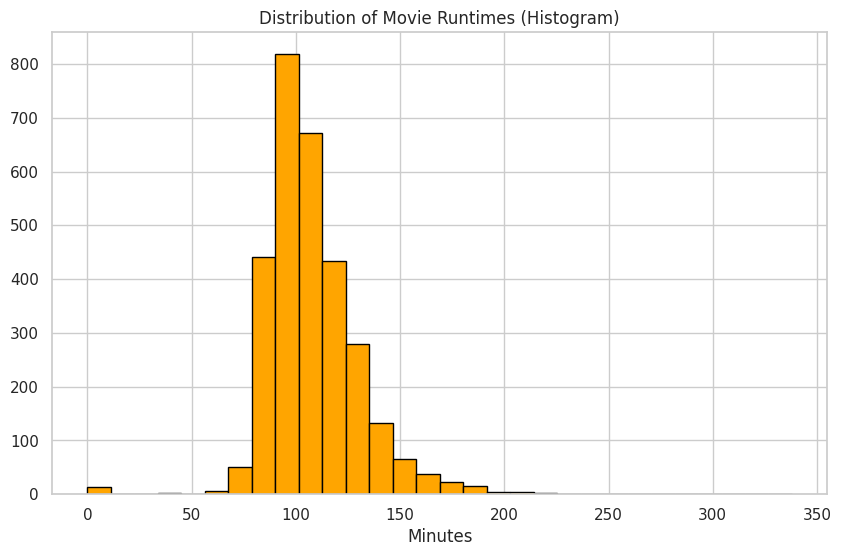

In [19]:
# 1. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[['budget', 'revenue', 'profit', 'popularity']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Analysis of Movie Financials")
plt.show()

# 2. Box Plot of Profit by Genre
df_exp = df.explode('genre_names')
top_genres = df_exp['genre_names'].value_counts().head(5).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='genre_names', y='profit', data=df_exp[df_exp['genre_names'].isin(top_genres)])
plt.yscale('log')
plt.title("Profit Distribution Across Top 5 Genres")
plt.show()

# 3. Distribution of Runtimes
plt.figure(figsize=(10, 6))
plt.hist(df['runtime'].dropna(), bins=30, color='orange', edgecolor='black')
plt.title("Distribution of Movie Runtimes (Histogram)")
plt.xlabel("Minutes")
plt.show()